In [ ]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sunpy.visualization.colormaps as sunpycm
import torch
from omegaconf import OmegaConf

from sdofmv2.core import (
    MAE, 
    SDOMLDataModule, 
    patch_attn_layers, 
    visualize_head)
from sdofmv2.utils import ALL_WAVELENGTHS

/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cfg = OmegaConf.load(
    "../../configs/pretrain/pretrain_mae_AIA.yaml"
    )

In [4]:
data_module = SDOMLDataModule(
    hmi_path=os.path.join(
        cfg.data.sdoml.base_directory, 
        cfg.data.sdoml.sub_directory.hmi
    ) if cfg.data.sdoml.sub_directory.hmi else None,
    aia_path=os.path.join(
        cfg.data.sdoml.base_directory,
        cfg.data.sdoml.sub_directory.aia,
    ) if cfg.data.sdoml.sub_directory.aia else None,
    eve_path=None,
    components=cfg.data.sdoml.components,
    wavelengths=cfg.data.sdoml.wavelengths,
    ions=cfg.data.sdoml.ions,
    frequency=cfg.data.sdoml.frequency,
    batch_size=cfg.model.misc.batch_size,
    num_workers=cfg.data.num_workers,
    val_months=cfg.data.month_splits.val,
    test_months=cfg.data.month_splits.test,
    holdout_months=cfg.data.month_splits.holdout,
    cache_dir=os.path.join(
        "../../assets/",
        cfg.data.sdoml.sub_directory.cache,
    ),
    min_date=cfg.data.min_date,
    max_date=cfg.data.max_date,
    num_frames=cfg.model.mae.num_frames,
    drop_frame_dim=cfg.data.drop_frame_dim,
    apply_mask=cfg.data.sdoml.apply_mask,
    precision=cfg.experiment.precision,
    normalization=cfg.data.sdoml.normalization,
)
data_module.setup()

[* CACHE SYSTEM *] Found cached index data in ../../assets/cache/aligndata_AIA_FULL_12min_2010-05-0100:00:00-2018-12-3123:59:59.csv.


2026-03-09 01:44:54.724 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/AIA/131A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-09 01:44:54.725 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/AIA/1600A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-09 01:44:54.725 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/AIA/1700A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-09 01:44:54.726 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/AIA/171A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-09 01:44:54.726 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/AIA/193A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-09 01:44:54.727 | INFO     | sdofmv2.core.datamodu

[* CACHE SYSTEM *] Found cached HMI mask data in ../../assets/cache/hmi_mask_512x512.npy.


In [5]:
base_path = "../../assets/check_point/backbone/"
model = MAE.load_from_checkpoint(
    checkpoint_path=base_path+"AIA/id_6lfzuk01_mae_epoch=76-val_loss=0.00.ckpt", 
    map_location="cpu",
    weights_only=False)
model.eval()

MAE(
  (autoencoder): MaskedAutoencoderViT3D(
    (patch_embed): PatchEmbed(
      (proj): Conv3d(9, 768, kernel_size=(1, 16, 16), stride=(1, 16, 16))
      (norm): Identity()
    )
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (act): GELU(approximate='none')
          (drop1): Dropout(p=0.0, inplace=False)
       

In [6]:
timestamps = [
    "2011-12-25 00:12:00",
    "2012-12-25 00:12:00",
    "2013-12-25 00:12:00",
    "2014-12-25 00:12:00",
    "2015-12-25 00:12:00",
    "2016-12-25 00:12:00",
    "2017-12-25 00:12:00",
    ]

img_indices = [
    data_module.test_ds.aligndata.index.get_loc(
        pd.to_datetime(i_time)
    ) for i_time in timestamps
]

x_set = torch.cat([data_module.test_ds[i][0].unsqueeze(0) for i in img_indices], dim=0)
ts = [pd.to_datetime(data_module.test_ds[i][1]) for i in img_indices]

print(f"Datetime: {ts}")

Datetime: [Timestamp('2011-12-25 00:12:00'), Timestamp('2012-12-25 00:12:00'), Timestamp('2013-12-25 00:12:00'), Timestamp('2014-12-25 00:12:00'), Timestamp('2015-12-25 00:12:00'), Timestamp('2016-12-25 00:12:00'), Timestamp('2017-12-25 00:12:00')]


In [7]:
wavelenghs = ALL_WAVELENGTHS
wavelenghs.sort()

wave_val_list = []
for wave in wavelenghs:
    val = wave[:-1]
    wave_val_list.append(int(val))

wave_arr = np.array(wave_val_list)
sort_ids = np.argsort(wave_arr)

cms = [
    sunpycm.cmlist.get("sdoaia131"),
    sunpycm.cmlist.get("sdoaia1600"),
    sunpycm.cmlist.get("sdoaia1700"),
    sunpycm.cmlist.get("sdoaia171"),
    sunpycm.cmlist.get("sdoaia193"),
    sunpycm.cmlist.get("sdoaia211"),
    sunpycm.cmlist.get("sdoaia304"),
    sunpycm.cmlist.get("sdoaia335"),
    sunpycm.cmlist.get("sdoaia94"),
]

In [9]:
# Patch attention layers
attn_maps = patch_attn_layers(model)

with torch.no_grad():
    latent, mask, ids_restore = model.autoencoder.forward_encoder(x_set, mask_ratio=0)
latent_size = latent.shape[1] - 1
ids_keep = torch.argsort(ids_restore.squeeze())[:latent_size]
feature_maps = latent[0, 1:, :]

In [10]:
attn_maps = patch_attn_layers(model)

with torch.no_grad():
    latent, mask, ids_restore = model.autoencoder.forward_encoder(x_set, mask_ratio=0)


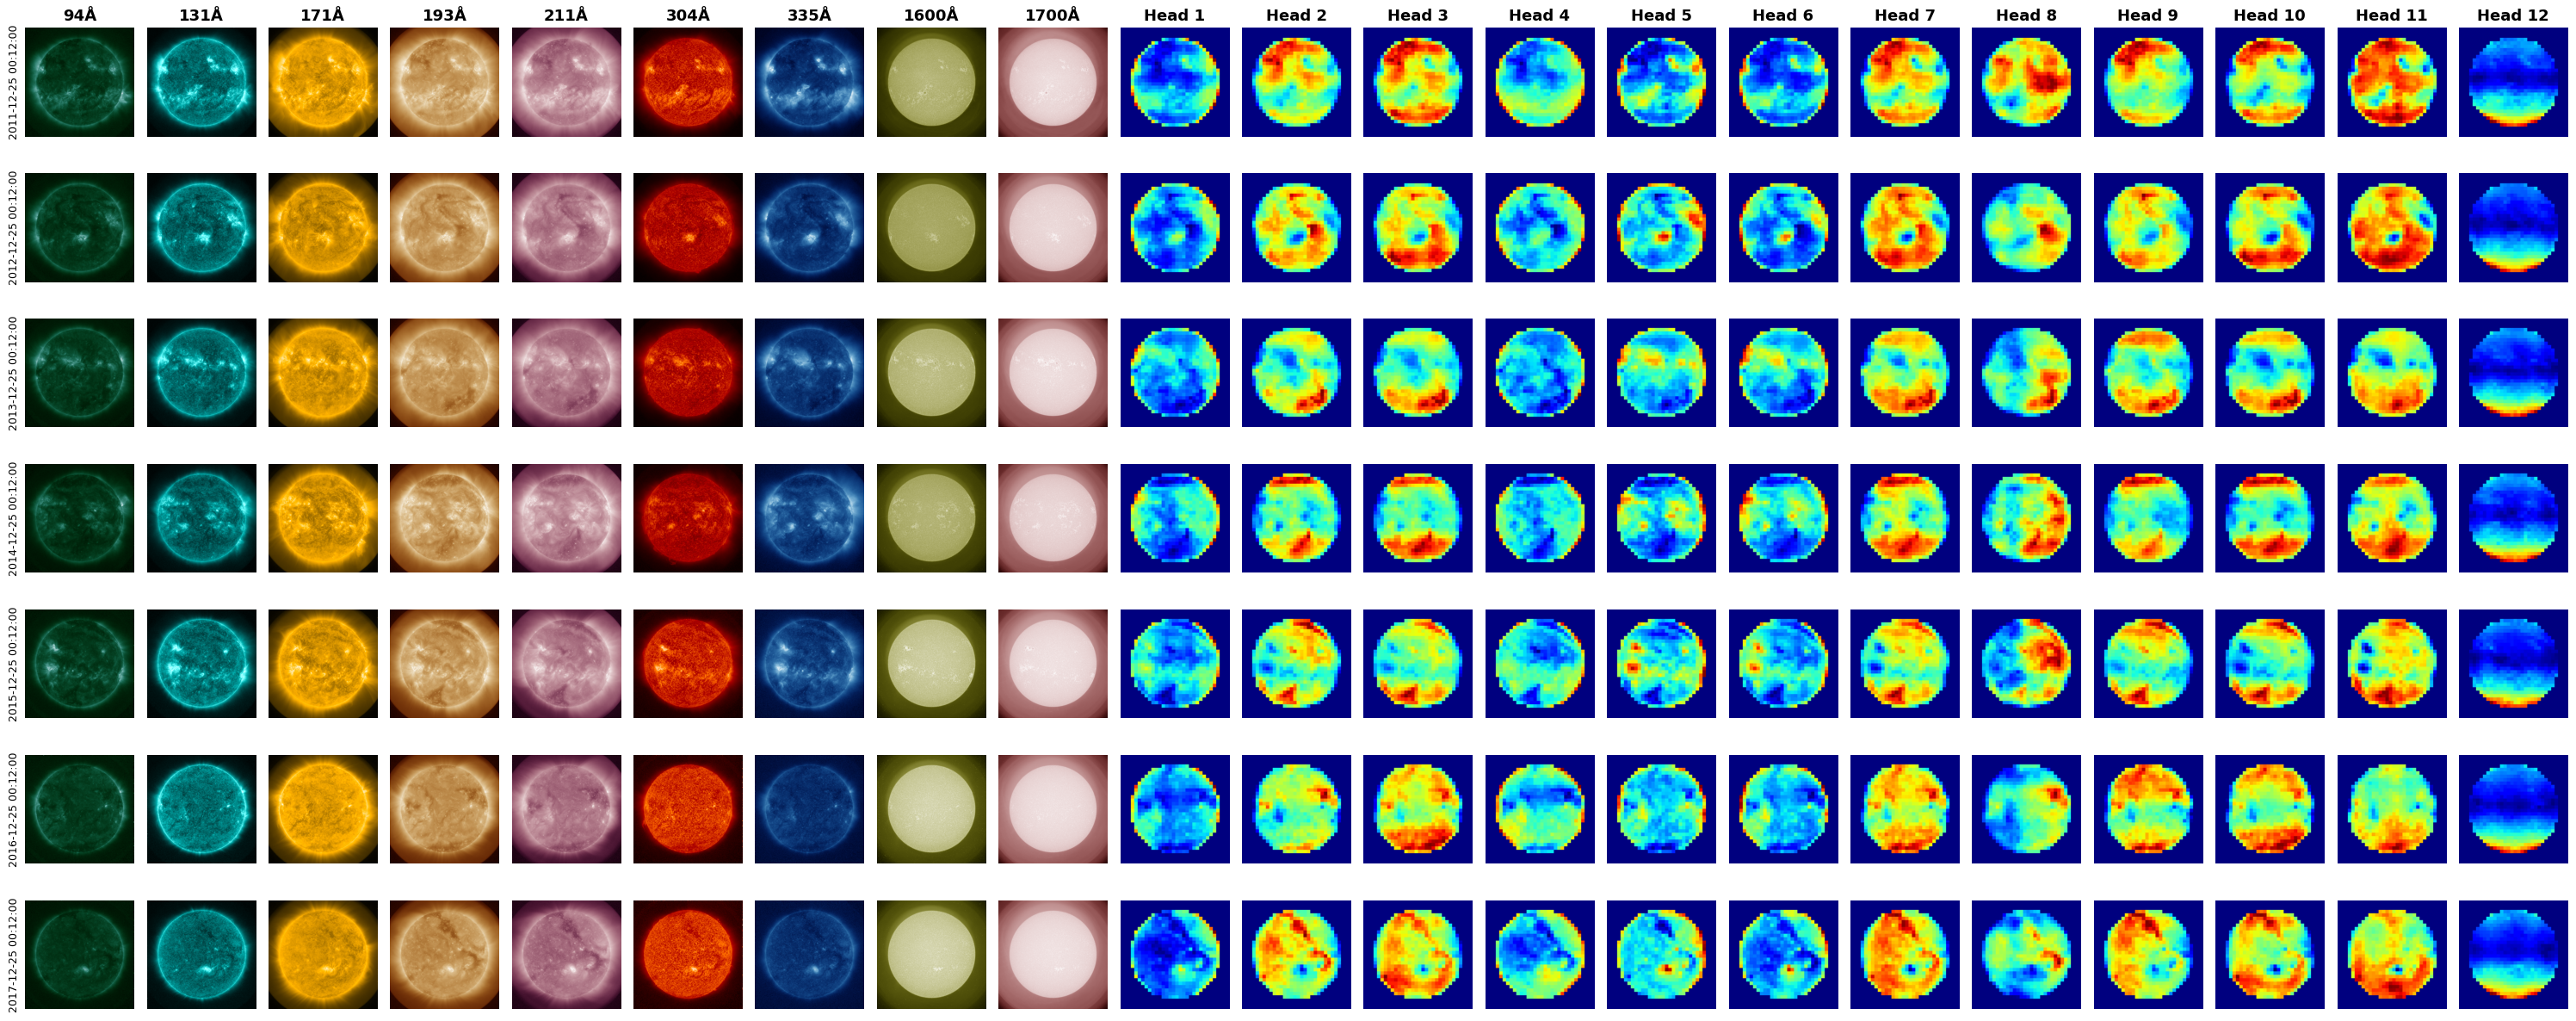

In [11]:
num_images = x_set.shape[0]
num_channels = x_set.shape[1]
num_heads = attn_maps[0].shape[1]
ch_info = ["131", "1600", "1700", "171", "193", "211", "304", "335", "94"]

fig, axs = plt.subplots(
    num_images, num_heads + num_channels, figsize=(30, 12), squeeze=False
)

for i in range(num_images):

    attn = attn_maps[0][i, :, 1:, 1:]  # [num_head, num_patch, num_patch]
    num_heads = attn.shape[0]
    full_order = torch.argsort(ids_restore[i])  # Invert argsort
    num_kept = attn.shape[1]
    ids_keep = full_order[:num_kept]
    attn_received = attn.mean(axis=1)

    for i_col, col in enumerate(sort_ids):
        if i==0:
            axs[i, i_col].set_title(f"{ch_info[col]}Å", fontsize=13, fontweight='bold')
        axs[i, i_col].imshow(x_set[i, col, 0, :, :], cmap=cms[col])
        axs[i, i_col].axis("off")

    for h in range(num_heads):
        if i==0:
            axs[i, h + num_channels].set_title(f"Head {h+1}", fontsize=13, fontweight='bold')
        head_attn = attn_received[h, :]
        heatmap = visualize_head(head_attn, ids_keep, 512, 16)
        axs[i, h + num_channels].imshow(heatmap, cmap="jet")
        axs[i, h + num_channels].axis("off")

    axs[i][0].text(
        -0.1, 0.5,              # Negative x moves it to the left
        f"{ts[i]}", 
        ha='center', 
        va='center', 
        fontsize=9, 
        rotation=90,
        transform=axs[i][0].transAxes # Ensures coordinates are relative to the subplot
    )

plt.tight_layout()
plt.savefig("attention_map_AIA.pdf", dpi=300, bbox_inches="tight")
# plt.show()